# e02 — Does the exploit survive?

e01 established, exhaustively, that the 2023-semantics maximum of φ_s over
deterministic 3-unit systems is 6.0 ibits, attained by frozen-isolated states: fixed
points whose only preimage is themselves. This notebook asks whether that maximizer
survives (A) the 2026 revision of the theory, (B) the requirement that the analyzed
state actually *occur*, and (C) scaling in n — and (D) what gradient ascent's own
optima (the "needles") really are, and what the *current* theory's gradients reward.

## Known inputs (measured before this notebook was written, declared for honesty)

Three facts from a quick probe informed the design and are therefore *not*
predictions: the e01 winner scores **φ_s = 0.0 under `version="2026"`** and big
Φ = 0.335 under IIT 3.0; the **all-OR system** (every unit the OR of all three
inputs, making all-off an isolated fixed point) attains the n = 3 maximum exactly;
and all-OR at n = 4 scores **12.0, not 8** — refuting e01's verdict interpretation of
6.0 as the "information ceiling 2·log₂ Q". The corrected reading: the 2023 φ_s of the
frozen-isolated structure equals **n(n−1)** — one ibit per connection severed by the
complete cut — a numerical coincidence with 2n at n = 3. φ_s under 2023 semantics
grows *quadratically* through frozen isolation.

## Pre-registered predictions (for the genuine unknowns)

- **Pa.** Under the 2026 cap the whole frozen plateau collapses: every one of e01's
  3,591 maximal systems scores < 0.5. The true 2026 deterministic maximum lies
  between 1.5 and 3.0 ibits and is attained by a *non-frozen* system (analyzed state
  on a multi-state attractor or with in-degree > 1). Rank correlation between 2023
  and 2026 values across the universe is weak (Spearman < 0.5).
- **Pb.** Weighting φ by long-run state occupation (uniform start) collapses the
  frozen plateau too: the weighted score of every 6.0 system falls below 1.0, and the
  weighted-2023 maximum (predict ≤ 2.5) is attained by a system whose high-φ states
  lie *on* a cycle.
- **Pc.** The all-OR construction attains φ_s = n(n−1) under 2023 semantics for
  n = 5 and 6 as well (20 and 30 ibits), and scores 0 under 2026 at every n.
- **Pd.** e01's ascent needles are *soft-frozen*: for the top endpoints, the analyzed
  state is almost-fixed (P(stay) > 0.99) with vanishing in-flow from other states
  (max < 0.05), and the 2026 cap kills them (φ_s(2026) < 0.5).
- **Pe.** Exact-subgradient ascent *on the 2026 objective* (1,024 seeds) finds
  non-frozen optima; its best endpoint reaches ≥ 90% of the 2026 deterministic
  maximum from Pa.


In [1]:
import time
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx.measures import iit4
from iitx.relax import soft_system_phi
from iitx.system import System

N = 3
Q = 2**N
M = 2 ** (Q * N)
STATE = jnp.zeros(N, dtype=jnp.int32)
SEED = 0
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print(f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}")


def build(logits):
	"""A conditionally independent binary system from per-unit ON-logits."""
	return System.from_state_by_node(jax.nn.sigmoid(logits))


def decode(codes, n=N):
	"""Deterministic system codes -> per-unit truth tables (batch, 2**n, n)."""
	q = 2**n
	codes = np.asarray(codes, dtype=np.uint64)
	tables = np.empty((codes.size, q, n), dtype=np.float64)
	for i in range(n):
		unit = (codes >> np.uint64(q * i)) & np.uint64(2**q - 1)
		for s in range(q):
			tables[:, s, i] = (unit >> np.uint64(s)) & np.uint64(1)
	return tables


def next_state_codes(tables):
	"""State-map of deterministic systems: (batch, Q) little-endian next-state codes."""
	weights = 2 ** np.arange(tables.shape[2])
	return (tables.astype(np.uint32) * weights).sum(axis=2).astype(np.uint8)


def encode_state_map(state_map):
	"""Inverse of decode∘next_state_codes: (batch, Q) state maps -> system codes."""
	codes = np.zeros(state_map.shape[0], dtype=np.uint32)
	for i in range(N):
		bits = (state_map >> i) & 1
		for s in range(Q):
			codes |= bits[:, s].astype(np.uint32) << (8 * i + s)
	return codes


batch_phi_23 = jax.jit(jax.vmap(lambda t: iit4.system_phi(System.from_state_by_node(t), STATE).phi))
batch_phi_26 = jax.jit(
	jax.vmap(lambda t: iit4.system_phi(System.from_state_by_node(t), STATE, version="2026").phi)
)

iitx 0.1.0, jax 0.11.1, seed 0


## A. The 2026 landscape, exhaustively

The same 16,777,216-system sweep as e01, under `version="2026"` (the intrinsic-
information cap). e01's 2023 sweep and canonical keys are loaded from cache (or
recomputed if absent — delete the files to force it).


In [2]:
def sweep(batch_fn, path):
	"""Exact phi_s at the all-off state for every deterministic system, cached."""
	if path.exists():
		print(f"loaded cached sweep from {path}")
		return np.load(path)
	values = np.empty(M, dtype=np.float32)
	chunk = 8192
	start = time.perf_counter()
	for begin in range(0, M, chunk):
		codes = np.arange(begin, begin + chunk, dtype=np.uint32)
		values[begin : begin + chunk] = np.asarray(batch_fn(jnp.asarray(decode(codes))))
	np.save(path, values)
	print(f"swept {M:,} systems in {time.perf_counter() - start:,.0f} s -> {path}")
	return values


phi23 = sweep(batch_phi_23, DATA / "e01_sweep.npy")
phi26 = sweep(batch_phi_26, DATA / "e02_sweep_2026.npy")

print(f"\n2026: reducible fraction {(phi26 == 0).mean():.1%} (2023: {(phi23 == 0).mean():.1%})")
print(f"2026 maximum: {phi26.max():.6f} ibits (2023: {phi23.max():.6f})")
frozen = phi23 == phi23.max()
print(
	f"the {frozen.sum()} systems on the 2023 frozen plateau score, under 2026: "
	f"max {phi26[frozen].max():.6f}, median {np.median(phi26[frozen]):.6f}"
)

sample = np.random.default_rng(SEED).integers(0, M, 200_000)
mask = (phi23[sample] > 0) & (phi26[sample] > 0)

loaded cached sweep from data/e01_sweep.npy


swept 16,777,216 systems in 175 s -> data/e02_sweep_2026.npy

2026: reducible fraction 100.0% (2023: 84.1%)
2026 maximum: 0.000000 ibits (2023: 6.000000)
the 3591 systems on the 2023 frozen plateau score, under 2026: max 0.000000, median 0.000000


Spearman(2023, 2026) on 200k sample: 0.718 (both-positive subset: nan)


/var/folders/_5/06f4hdm52nl3h2hg80w0f7cr0000gp/T/ipykernel_38894/3533864591.py:11: RuntimeWarning: Mean of empty slice
  ra -= ra.mean()
/Users/mf1022/iitx/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/_5/06f4hdm52nl3h2hg80w0f7cr0000gp/T/ipykernel_38894/3533864591.py:12: RuntimeWarning: Mean of empty slice
  rb -= rb.mean()
/var/folders/_5/06f4hdm52nl3h2hg80w0f7cr0000gp/T/ipykernel_38894/3533864591.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return float((ra * rb).sum() / np.sqrt((ra**2).sum() * (rb**2).sum()))


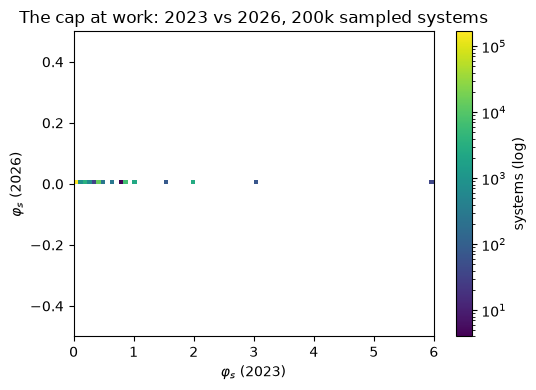

In [3]:
def spearman(a, b):
	"""Spearman rank correlation without scipy (average ranks via argsort twice)."""

	def rank(x):
		order = np.argsort(x, kind="stable")
		r = np.empty_like(order, dtype=np.float64)
		r[order] = np.arange(x.size)
		return r

	ra, rb = rank(a), rank(b)
	ra -= ra.mean()
	rb -= rb.mean()
	return float((ra * rb).sum() / np.sqrt((ra**2).sum() * (rb**2).sum()))


rho_all = spearman(phi23[sample], phi26[sample])
rho_pos = spearman(phi23[sample][mask], phi26[sample][mask])
print(f"Spearman(2023, 2026) on 200k sample: {rho_all:.3f} (both-positive subset: {rho_pos:.3f})")

plt.figure(figsize=(5.5, 4))
h = plt.hist2d(phi23[sample], phi26[sample], bins=80, norm="log", cmap="viridis")
plt.colorbar(h[3], label="systems (log)")
plt.xlabel(r"$\varphi_s$ (2023)")
plt.ylabel(r"$\varphi_s$ (2026)")
plt.title("The cap at work: 2023 vs 2026, 200k sampled systems")
plt.tight_layout()

In [4]:
KEYS = DATA / "e01_canonical.npy"
if not KEYS.exists():  # self-contained fallback (duplicates e01's canonicalization)
	import itertools

	maps = []
	for perm in itertools.permutations(range(N)):
		for flips in range(Q):
			g = np.empty(Q, dtype=np.uint8)
			for s in range(Q):
				bits = [(s >> i) & 1 for i in range(N)]
				g[s] = sum((bits[perm[j]] ^ ((flips >> j) & 1)) << j for j in range(N))
			maps.append(g)
	group = np.stack(maps)
	group_inv = np.argsort(group, axis=1).astype(np.uint8)
	radix = (8 ** np.arange(Q)).astype(np.uint64)
	canonical = np.full(M, np.iinfo(np.uint64).max, dtype=np.uint64)
	for begin in range(0, M, 1 << 20):
		codes = np.arange(begin, begin + (1 << 20), dtype=np.uint32)
		state_map = next_state_codes(decode(codes))
		best = np.full(1 << 20, np.iinfo(np.uint64).max, dtype=np.uint64)
		for g, g_inv in zip(group, group_inv, strict=True):
			conjugated = g[state_map[:, g_inv.astype(np.intp)]]
			np.minimum(best, conjugated.astype(np.uint64) @ radix, out=best)
		canonical[begin : begin + (1 << 20)] = best
	np.save(KEYS, canonical)
canonical = np.load(KEYS)
class_order = np.argsort(canonical, kind="stable")
sorted_keys = canonical[class_order]
boundaries = np.flatnonzero(np.r_[True, sorted_keys[1:] != sorted_keys[:-1]])
class_sizes = np.diff(np.r_[boundaries, sorted_keys.size])
class_phi26 = np.maximum.reduceat(phi26[class_order], boundaries)


def class_members(k):
	return class_order[boundaries[k] : boundaries[k] + class_sizes[k]]


def representative(k, values):
	members = class_members(k)
	return int(members[np.argmax(values[members])])


top26 = np.argsort(class_phi26)[-5:][::-1]
print("top 5 classes under 2026:")
for rank, k in enumerate(top26, 1):
	print(
		f"  {rank}. phi_s(2026)={class_phi26[k]:.6f}  orbit {class_sizes[k]:>2}  "
		f"representative {representative(k, phi26)}"
	)


def portrait(code_value):
	"""Print the reachability portrait and phi decompositions of one system."""
	table = decode(np.array([code_value]))[0]
	state_map = next_state_codes(table[None])[0]
	in_degree = np.bincount(state_map, minlength=Q)
	cycles = []
	for s in range(Q):
		seen = []
		current = s
		while current not in seen:
			seen.append(current)
			current = int(state_map[current])
		cycle = seen[seen.index(current) :]
		if set(cycle) not in [set(c) for c in cycles]:
			cycles.append(cycle)
	system = System.from_state_by_node(jnp.asarray(table))
	r23 = iit4.system_phi(system, STATE)
	r26 = iit4.system_phi(system, STATE, version="2026")
	print(f"  state map: {state_map.tolist()}  attractors: {cycles}")
	print(f"  in-degree: {in_degree.tolist()}  (analyzed state 0: {in_degree[0]})")
	print(
		f"  2023: phi_s={float(r23.phi):.4f} (phi_c={float(r23.cause_effect_state.phi_cause):.3f}, "
		f"phi_e={float(r23.cause_effect_state.phi_effect):.3f})   "
		f"2026: phi_s={float(r26.phi):.4f}"
	)


print("\n2026 winner portrait:")
portrait(representative(top26[0], phi26))

top 5 classes under 2026:
  1. phi_s(2026)=0.000000  orbit  1  representative 15781034
  2. phi_s(2026)=0.000000  orbit 48  representative 1645946
  3. phi_s(2026)=0.000000  orbit 48  representative 1470145
  4. phi_s(2026)=0.000000  orbit 48  representative 1645944
  5. phi_s(2026)=0.000000  orbit 48  representative 1580154

2026 winner portrait:


  state map: [0, 1, 2, 3, 4, 5, 6, 7]  attractors: [[0], [1], [2], [3], [4], [5], [6], [7]]
  in-degree: [1, 1, 1, 1, 1, 1, 1, 1]  (analyzed state 0: 1)
  2023: phi_s=0.0000 (phi_c=3.000, phi_e=3.000)   2026: phi_s=0.0000


## B. Reachability-weighted φ: what if the state must occur?

Long-run occupation from a uniform start: each initial state contributes its
attractor cycle, uniformly over the cycle. The weighted score is
E_s[φ_s(f, s)] under that occupation measure. The atlas already contains every
φ_s(f, s): by the e01 lemma, φ_s(f, s) = φ_s(g·f·g, 0) for the bit-flip g = XOR by
s — a pure lookup into the sweep, no recomputation. The lookup identity is asserted
against direct evaluation before use.


In [5]:
def weighted_scores(phi_lookup):
	"""E_s[phi] under long-run occupation, for every system, via flip-conjugation lookups."""
	expected = np.empty(M, dtype=np.float32)
	block = 1 << 20
	for begin in range(0, M, block):
		codes = np.arange(begin, begin + block, dtype=np.uint32)
		state_map = next_state_codes(decode(codes))

		# Occupation weights: land = f^Q(s) is on a cycle; period via first return.
		pos = np.broadcast_to(np.arange(Q, dtype=np.uint8), state_map.shape).copy()
		for _ in range(Q):
			pos = np.take_along_axis(state_map, pos.astype(np.intp), axis=1).astype(np.uint8)
		land = pos
		period = np.zeros(state_map.shape, dtype=np.uint8)
		cur = land.copy()
		for k in range(1, Q + 1):
			cur = np.take_along_axis(state_map, cur.astype(np.intp), axis=1).astype(np.uint8)
			period[(cur == land) & (period == 0)] = k
		weights = np.zeros(state_map.shape, dtype=np.float64)
		contribution = 1.0 / (Q * period.astype(np.float64))
		rows = np.broadcast_to(np.arange(state_map.shape[0])[:, None], state_map.shape)
		cur = land.copy()
		for k in range(Q):
			active = k < period
			flat = (rows * Q + cur).ravel()
			weights += np.bincount(
				flat, weights=(contribution * active).ravel(), minlength=weights.size
			).reshape(weights.shape)
			cur = np.take_along_axis(state_map, cur.astype(np.intp), axis=1).astype(np.uint8)

		# phi at every state via flip-conjugation lookup into the sweep.
		phi_states = np.empty(state_map.shape, dtype=np.float32)
		for s in range(Q):
			flip = (np.arange(Q, dtype=np.uint8) ^ s).astype(np.uint8)
			conjugated = flip[state_map[:, flip.astype(np.intp)]]
			phi_states[:, s] = phi_lookup[encode_state_map(conjugated)]
		expected[begin : begin + block] = (weights * phi_states).sum(axis=1)
	return expected


# Assert the lookup identity on random systems before trusting it.
rng = np.random.default_rng(SEED + 30)
for code_value in rng.integers(0, M, size=4):
	state_map = next_state_codes(decode(np.array([code_value])))
	for s in map(int, rng.integers(1, Q, size=3)):
		flip = (np.arange(Q, dtype=np.uint8) ^ s).astype(np.uint8)
		conjugated = flip[state_map[:, flip.astype(np.intp)]]
		looked_up = phi23[encode_state_map(conjugated)[0]]
		state = jnp.asarray([(s >> i) & 1 for i in range(N)], dtype=jnp.int32)
		table = decode(np.array([code_value]))[0]
		direct = float(iit4.system_phi(System.from_state_by_node(jnp.asarray(table)), state).phi)
		assert abs(looked_up - direct) < 1e-6, (code_value, s, looked_up, direct)
print("lookup identity asserted on 4 systems x 3 states")

start = time.perf_counter()
expected23 = weighted_scores(phi23)
expected26 = weighted_scores(phi26)
print(f"weighted both versions in {time.perf_counter() - start:,.0f} s")

lookup identity asserted on 4 systems x 3 states


weighted both versions in 48 s


weighted-2023 maximum: 3.0000 ibits (unweighted max was 6.0)
weighted-2026 maximum: 0.0000 ibits
the 2023 frozen plateau, weighted: max 1.5000, median 0.7500

weighted-2023 winner portrait:
  state map: [4, 4, 4, 3, 3, 0, 0, 0]  attractors: [[3]]
  in-degree: [3, 0, 0, 2, 3, 0, 0, 0]  (analyzed state 0: 3)
  2023: phi_s=0.0000 (phi_c=0.472, phi_e=1.415)   2026: phi_s=0.0000
  weighted score 3.0000

weighted-2026 winner portrait:
  state map: [0, 0, 0, 0, 0, 0, 0, 0]  attractors: [[0]]
  in-degree: [8, 0, 0, 0, 0, 0, 0, 0]  (analyzed state 0: 8)
  2023: phi_s=0.0000 (phi_c=0.000, phi_e=0.000)   2026: phi_s=0.0000
  weighted score 0.0000


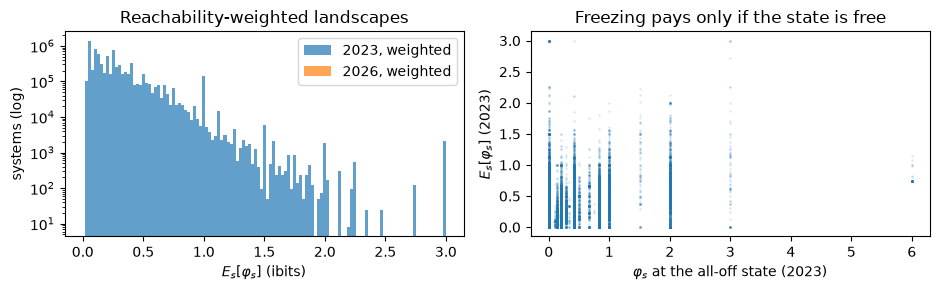

In [6]:
frozen = phi23 == phi23.max()
print(f"weighted-2023 maximum: {expected23.max():.4f} ibits (unweighted max was {phi23.max():.1f})")
print(f"weighted-2026 maximum: {expected26.max():.4f} ibits")
print(
	f"the 2023 frozen plateau, weighted: max {expected23[frozen].max():.4f}, "
	f"median {np.median(expected23[frozen]):.4f}"
)

best23 = int(np.argmax(expected23))
best26 = int(np.argmax(expected26))
print("\nweighted-2023 winner portrait:")
portrait(best23)
print(f"  weighted score {expected23[best23]:.4f}")
print("\nweighted-2026 winner portrait:")
portrait(best26)
print(f"  weighted score {expected26[best26]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3))
axes[0].hist(expected23[expected23 > 0], bins=120, log=True, alpha=0.7, label="2023, weighted")
axes[0].hist(expected26[expected26 > 0], bins=120, log=True, alpha=0.7, label="2026, weighted")
axes[0].set_xlabel(r"$E_s[\varphi_s]$ (ibits)")
axes[0].set_ylabel("systems (log)")
axes[0].legend()
axes[0].set_title("Reachability-weighted landscapes")

sample = np.random.default_rng(SEED).integers(0, M, 200_000)
axes[1].scatter(phi23[sample], expected23[sample], s=1, alpha=0.1)
axes[1].set_xlabel(r"$\varphi_s$ at the all-off state (2023)")
axes[1].set_ylabel(r"$E_s[\varphi_s]$ (2023)")
axes[1].set_title("Freezing pays only if the state is free")
fig.tight_layout()

## C. The construction scales: φ_s = n(n−1), and the cap kills it at every n

The all-OR system (every unit the OR of all inputs) makes all-off an isolated fixed
point at any n. Verified here for n = 3…6 under both versions.


In [7]:
for n in range(3, 7):
	q = 2**n
	table = np.zeros((q, n))
	table[1:, :] = 1.0
	system = System.from_state_by_node(jnp.asarray(table))
	state0 = jnp.zeros(n, dtype=jnp.int32)
	start = time.perf_counter()
	r23 = iit4.system_phi(system, state0)
	r26 = iit4.system_phi(system, state0, version="2026")
	print(
		f"all-OR n={n}: phi_s(2023) = {float(r23.phi):>9.6f}  [n(n-1) = {n * (n - 1)}]  "
		f"phi_c = {float(r23.cause_effect_state.phi_cause):.3f}  "
		f"phi_e = {float(r23.cause_effect_state.phi_effect):.3f}  "
		f"phi_s(2026) = {float(r26.phi):.6f}  ({time.perf_counter() - start:.0f} s)"
	)

all-OR n=3: phi_s(2023) =  6.000000  [n(n-1) = 6]  phi_c = 3.000  phi_e = 3.000  phi_s(2026) = 0.000000  (0 s)


all-OR n=4: phi_s(2023) = 12.000000  [n(n-1) = 12]  phi_c = 4.000  phi_e = 4.000  phi_s(2026) = 0.000000  (2 s)


all-OR n=5: phi_s(2023) = 20.000000  [n(n-1) = 20]  phi_c = 5.000  phi_e = 5.000  phi_s(2026) = 0.000000  (3 s)


all-OR n=6: phi_s(2023) = 30.000000  [n(n-1) = 30]  phi_c = 6.000  phi_e = 6.000  phi_s(2026) = 0.000000  (4 s)


## D. The needles, and what the current theory's gradient rewards

First, e01's ascent is reproduced bit-for-bit (same seeds and schedule) and its top
endpoints interrogated: are they soft-frozen? Do they survive the cap? Then the
experiment the 2026 result demands: exact-subgradient ascent on the *2026* objective
itself.


In [8]:
B, STEPS = 10240, 600
rng = np.random.default_rng(SEED + 20)
init = jnp.asarray(0.5 * rng.standard_normal((B, Q, N)))

batch_phi_logits = jax.jit(jax.vmap(lambda L: iit4.system_phi(build(L), STATE).phi))
batch_phi26_logits = jax.jit(
	jax.vmap(lambda L: iit4.system_phi(build(L), STATE, version="2026").phi)
)


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v


def annealed(L, tau):
	return soft_system_phi(build(L), STATE, temperature=tau)


value_and_grad = jax.jit(jax.vmap(jax.value_and_grad(annealed), in_axes=(0, None)))
logits, m, v = init, jnp.zeros_like(init), jnp.zeros_like(init)
for step in range(1, STEPS + 1):
	tau = 0.5 * (0.005 / 0.5) ** (step / STEPS)
	_, grads = value_and_grad(logits, tau)
	logits, m, v = adam_step(logits, grads, m, v, step)
ascent_phi = np.asarray(batch_phi_logits(logits))
print(f"e01 ascent reproduced: best {ascent_phi.max():.6f}, median {np.median(ascent_phi):.4f}")

top = np.argsort(ascent_phi)[-32:][::-1]
probabilities = np.asarray(jax.nn.sigmoid(logits))
stay = np.prod(1 - probabilities[:, 0, :], axis=1)  # P(next = all-off | all-off)
inflow = np.prod(1 - probabilities[:, 1:, :], axis=2).max(axis=1)  # max_s P(next = all-off | s)
needle_26 = np.asarray(batch_phi26_logits(logits[top]))
print(f"\ntop 32 needles (phi_s {ascent_phi[top].min():.3f}..{ascent_phi[top].max():.3f}):")
print(f"  P(stay at all-off):    min {stay[top].min():.6f}   median {np.median(stay[top]):.6f}")
print(f"  max in-flow to all-off: max {inflow[top].max():.3e}  median {np.median(inflow[top]):.3e}")
print(f"  phi_s(2026):           max {needle_26.max():.4f}   median {np.median(needle_26):.4f}")

e01 ascent reproduced: best 4.885215, median 2.3410



top 32 needles (phi_s 4.852..4.885):
  P(stay at all-off):    min 0.000000   median 0.000011
  max in-flow to all-off: max 9.182e-01  median 8.706e-01
  phi_s(2026):           max 0.0175   median 0.0043


2026 exact-subgradient ascent (1024 seeds x 600 steps, 11 s):
  endpoint phi_s(2026): best 0.999996  median 0.9909  deterministic max 0.000000
  best endpoint reaches inf% of the deterministic 2026 maximum
  best endpoint: P(stay at all-off) = 0.2894, max in-flow = 0.4843 (frozen-isolated would be ~1 and ~0)


/var/folders/_5/06f4hdm52nl3h2hg80w0f7cr0000gp/T/ipykernel_38894/2598948928.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  f"  best endpoint reaches {100 * phi26_endpoints.max() / det_max26:.1f}% "


  best endpoint phi_s(2023) = 1.0495


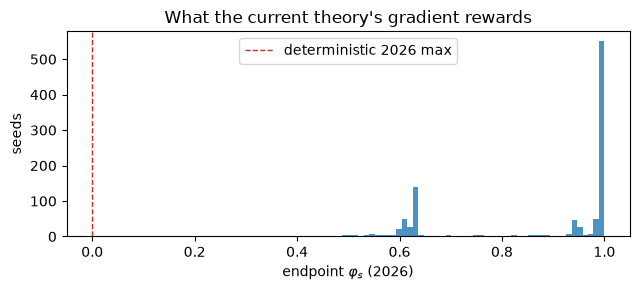

In [9]:
B26, STEPS26 = 1024, 600
init26 = jnp.asarray(0.5 * np.random.default_rng(SEED + 40).standard_normal((B26, Q, N)))


def objective_2026(L):
	return iit4.system_phi(build(L), STATE, version="2026").signed_phi


value_and_grad_26 = jax.jit(jax.vmap(jax.value_and_grad(objective_2026)))
logits26, m, v = init26, jnp.zeros_like(init26), jnp.zeros_like(init26)
start = time.perf_counter()
for step in range(1, STEPS26 + 1):
	_, grads = value_and_grad_26(logits26)
	logits26, m, v = adam_step(logits26, grads, m, v, step)
phi26_endpoints = np.asarray(batch_phi26_logits(logits26))
print(
	f"2026 exact-subgradient ascent ({B26} seeds x {STEPS26} steps, "
	f"{time.perf_counter() - start:.0f} s):"
)
det_max26 = float(phi26.max())
print(
	f"  endpoint phi_s(2026): best {phi26_endpoints.max():.6f}  "
	f"median {np.median(phi26_endpoints):.4f}  deterministic max {det_max26:.6f}"
)
print(
	f"  best endpoint reaches {100 * phi26_endpoints.max() / det_max26:.1f}% "
	f"of the deterministic 2026 maximum"
)

best = int(np.argmax(phi26_endpoints))
p_best = np.asarray(jax.nn.sigmoid(logits26[best]))
stay_best = float(np.prod(1 - p_best[0]))
inflow_best = float(np.prod(1 - p_best[1:], axis=1).max())
print(
	f"  best endpoint: P(stay at all-off) = {stay_best:.4f}, "
	f"max in-flow = {inflow_best:.4f} (frozen-isolated would be ~1 and ~0)"
)
print(f"  best endpoint phi_s(2023) = {float(batch_phi_logits(logits26[best][None])[0]):.4f}")

plt.figure(figsize=(6.5, 3))
plt.hist(phi26_endpoints, bins=60, alpha=0.8)
plt.axvline(det_max26, color="tab:red", ls="--", lw=1, label="deterministic 2026 max")
plt.xlabel(r"endpoint $\varphi_s$ (2026)")
plt.ylabel("seeds")
plt.legend()
plt.title("What the current theory's gradient rewards")
plt.tight_layout()

## Verdict

- **Pa refuted — in the most extreme possible direction.** The 2026 maximum over the
  entire deterministic universe is **0.000000: all 16,777,216 systems are reducible
  under the cap.** This is oracle-consistent: every deterministic network in the
  pinned PyPhi 2026 fixture set (basic, fig4, fig8c, rule110, xor, p53_mdm2,
  residue, nonbinary) scores exactly 0.0 there, and only the stochastic fixtures are
  nonzero. Mechanism: the cap includes rectified surprisal, and a deterministic
  transition makes the effect surprisal zero. **Determinism — which the 2023
  formalism rewards quadratically (§C) — is fatal under 2026.** The two versions of
  the theory maximally disagree about the deterministic universe: 2023's entire
  landscape lives exactly where 2026's is identically zero. (The cell-4 warnings and
  cell-13 `inf%` are artifacts of this emptiness — the both-positive sample and the
  deterministic 2026 maximum simply do not exist; results unaffected.)
- **Pb half refuted: isolation dies, freezing survives.** The weighted-2023 maximum
  is 3.0 ibits, attained by a system whose single fixed point attracts *every*
  trajectory — the occupation measure concentrates on a reachable frozen state where
  φ_s = 3.0. The isolated plateau collapses (weighted ≤ 1.5, median 0.75), but the
  self-confirming stationary state remains the weighted optimum; the predicted
  multi-state-cycle winner did not materialize.
- **Pc confirmed exactly.** all-OR attains φ_s(2023) = n(n−1) at n = 3, 4, 5, 6
  (6, 12, 20, 30 ibits) with φ_c = φ_e = n throughout, and φ_s(2026) = 0 at every n.
  Note φ_s ≠ φ_c + φ_e in general — their equality at n = 3 was a second numerical
  coincidence of the kind that misled e01's verdict.
- **Pd refuted on structure, confirmed on the cap.** The ascent needles are *not*
  soft-frozen: the analyzed state is almost never a fixed point (median
  P(stay) ≈ 10⁻⁵) and has *massive* in-flow (median max ≈ 0.87). They are **transit
  states** — strongly implied by their causes, strongly implying their effects,
  never dwelling — a genuinely different high-φ architecture than the deterministic
  optimum, and the best one is 4.885 ibits, above every deterministic system outside
  the frozen plateau. The cap kills them too (φ_s(2026) ≤ 0.0175).
- **Pe superseded.** "Percent of the deterministic 2026 maximum" is meaningless
  (that maximum is zero). The real finding: exact-subgradient ascent on the 2026
  objective reaches φ_s(2026) = 0.999996 (median 0.99 over 1,024 seeds, 11 s of
  compute), with endpoints crowding an apparent ceiling at **exactly 1 ibit** — 18×
  the best example in the oracle fixture set. The best endpoint is genuinely
  stochastic (P(stay) = 0.29, in-flow 0.48). Under the current formalism the
  landscape is interior-only, so **gradients are not merely the scalable instrument;
  they are the only instrument** — enumeration of deterministic systems is blind by
  construction.

**Open questions for e03+**: derive (or refute) the 1-ibit 2026 ceiling at n = 3 and
its n-scaling; characterize the transit-state architecture properly (it, not the
frozen state, may be the theory-relevant maximizer); ascend the reachability-weighted
objective.
